# Python claim classifier — preprocessing, training and evaluation

Evidence for SRS 1.10.4. This notebook calls the same functions as `src/ml/scripts/train_model.py`, which is what saves the model file the app uses (`model/python_v2.joblib`). Nothing here is typed in by hand: every number is computed below.

Procedure: 5-fold cross-validation on train → each algorithm scored on validation → best validation accuracy selected → refitted on train + validation → scored once on test.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import os; os.chdir(ROOT)
from src.ml.scripts import train_model as tm   # (the script itself draws charts to files)
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

## 1. Dataset

One common dataset of 1,500 synthetic claims (500 per class), split 70/15/15 with stratification before any card image was drawn. Generated by `dataset_generator/generator.py`; field meanings in `data/data_dictionary.md`.

In [2]:
X_train, y_train = tm.load_dataset('claims_train.csv')
X_val, y_val = tm.load_dataset('claims_val.csv')
X_test, y_test = tm.load_dataset('claims_test.csv')
pd.DataFrame({'train': y_train.value_counts(), 'validation': y_val.value_counts(), 'test': y_test.value_counts()})

,train,validation,test
label,,,
Invalid Claim,350,72,75
Manual Review,352,82,71
Valid Claim,348,71,79


In [3]:
X_train.head()

,product_age_days,warranty_months,warranty_days_left,days_purchase_to_fault,previous_repairs,missing_documents,product_category,fault_category,product_replaced_before,physical_damage,water_damage,receipt_present,warranty_card_present,product_image_present,repair_report_present,serial_matches
0,360,12,0,360,3,0,consumer_electronics,motherboard,0,0,0,1,0,1,1,1
1,152,24,568,76,4,0,small_appliances,manufacturing_defect,1,0,0,1,1,1,1,1
2,110,12,250,19,0,0,mobile_devices,cosmetic_wear,0,1,0,1,1,1,0,1
3,360,12,0,360,2,0,mobile_devices,display,0,0,0,1,0,1,1,1
4,271,12,89,91,3,0,mobile_devices,speaker_or_microphone,0,0,0,1,0,1,1,1


## 2. Preprocessing and feature engineering

- **Derived features** (made by the generator for the dataset, and by `src/ml/features.py` for live claims): product age, warranty days left, days from purchase to fault, count of missing mandatory documents.
- **Missing values**: the generator produces none; for live claims, no fault date → 0 days and an unknown fault → `unknown`. The one-hot encoder ignores categories it has not seen.
- **Categorical encoding**: one-hot for `product_category` and `fault_category`.
- **Scaling**: `StandardScaler` on the six numeric features; the eight yes/no flags pass through as 0/1.

In [4]:
pre = tm.build_preprocessor().fit(X_train)
names = pre.get_feature_names_out()
print(len(tm.ALL_FEATURES), 'input features ->', len(names), 'model columns')
pd.DataFrame(pre.transform(X_train.head(3)), columns=names).round(2).T.head(15)

16 input features -> 40 model columns


,0,1,2
num__product_age_days,0.12,-0.87,-1.07
num__warranty_months,-0.75,1.34,-0.75
num__warranty_days_left,-0.88,2.34,0.54
num__days_purchase_to_fault,0.53,-0.70,-0.95
num__previous_repairs,1.33,1.97,-0.60
num__missing_documents,-0.28,-0.28,-0.28
cat__product_category_consumer_electronics,1.00,0.00,0.00
cat__product_category_mobile_devices,0.00,0.00,1.00
cat__product_category_small_appliances,0.00,1.00,0.00
cat__fault_category_battery,0.00,0.00,0.00


## 3. Algorithms compared and cross-validation

Three algorithms with the hyperparameters below, 5-fold stratified cross-validation on the training split.

In [5]:
pd.DataFrame({n: {k: v for k, v in c.get_params().items() if k in ('n_estimators', 'max_depth', 'learning_rate', 'max_iter')}
              for n, c in tm.CANDIDATES.items()}).T

,max_depth,n_estimators,learning_rate,max_iter
RandomForest,12.0,150.0,NaN,NaN
GradientBoosting,5.0,120.0,0.1,NaN
LogisticRegression,NaN,NaN,NaN,1000.0


In [6]:
cv = tm.cross_validate_all(X_train, y_train)
pd.DataFrame({n: {'mean': r['mean'], 'std': r['std'], **{f'fold {i + 1}': s for i, s in enumerate(r['folds'])}} for n, r in cv.items()}).T

,mean,std,fold 1,fold 2,fold 3,fold 4,fold 5
RandomForest,0.9476,0.0188,0.9429,0.9762,0.9619,0.9286,0.9286
GradientBoosting,0.9438,0.0155,0.9286,0.9571,0.9667,0.9381,0.9286
LogisticRegression,0.7229,0.0174,0.6952,0.7095,0.7381,0.7333,0.7381


## 4. Validation results and model selection

In [7]:
val = {n: tm.evaluate(tm.make_pipeline(n).fit(X_train, y_train), X_val, y_val) for n in tm.CANDIDATES}
best = max(val, key=lambda n: val[n]['accuracy'])
print('Selected:', best)
pd.DataFrame({n: {'accuracy': m['accuracy'], 'precision (macro)': m['precision_macro'],
                  'recall (macro)': m['recall_macro'], 'F1 (macro)': m['f1_macro']} for n, m in val.items()}).T

Selected: RandomForest


,accuracy,precision (macro),recall (macro),F1 (macro)
RandomForest,0.9422,0.9432,0.9437,0.9419
GradientBoosting,0.9111,0.9114,0.9135,0.9111
LogisticRegression,0.6444,0.6725,0.6495,0.6454


In [8]:
print(val[best]['report'])

               precision    recall  f1-score   support

  Valid Claim      0.886     0.986     0.933        71
Invalid Claim      0.944     0.931     0.937        72
Manual Review      1.000     0.915     0.955        82

     accuracy                          0.942       225
    macro avg      0.943     0.944     0.942       225
 weighted avg      0.946     0.942     0.943       225



## 5. Final model on the test split

The selected pipeline is refitted on train + validation and scored once on test. SRS target: at least 85% accuracy on unseen claims.

In [9]:
final = tm.make_pipeline(best).fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
test = tm.evaluate(final, X_test, y_test)
print(f"Test accuracy: {test['accuracy']:.2%}")
print(test['report'])

Test accuracy: 94.22%
               precision    recall  f1-score   support

  Valid Claim      0.948     0.924     0.936        79
Invalid Claim      0.944     0.907     0.925        75
Manual Review      0.934     1.000     0.966        71

     accuracy                          0.942       225
    macro avg      0.942     0.944     0.942       225
 weighted avg      0.942     0.942     0.942       225



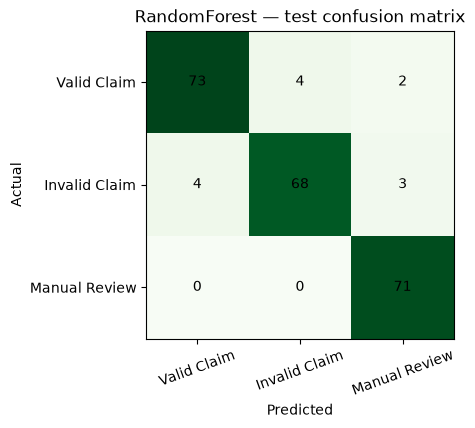

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = test['confusion_matrix']
ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(3), tm.LABELS, rotation=20); ax.set_yticks(range(3), tm.LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i][j], ha='center', va='center')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'{best} — test confusion matrix')
plt.show()

## 6. Feature importance

Random Forest importances, with each category's one-hot columns added back together. The optional warranty card and repair report are near the bottom: dataset v2 removed the shortcut that v1 of the dataset allowed (see DEVLOG, 29 Sep).

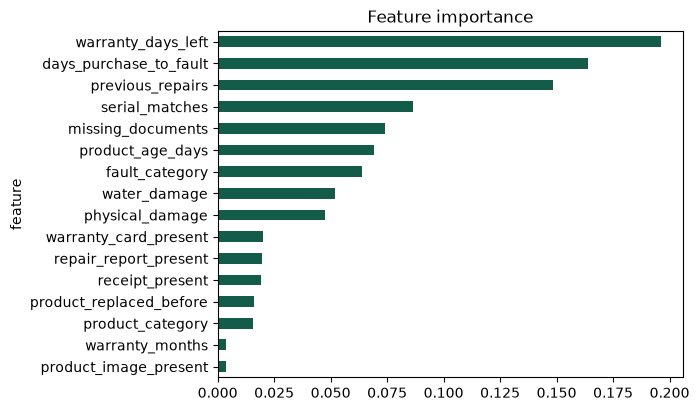

,importance
feature,
warranty_days_left,0.1960
days_purchase_to_fault,0.1638
previous_repairs,0.1486
serial_matches,0.0863
missing_documents,0.0740
product_age_days,0.0694
fault_category,0.0638
water_damage,0.0521
physical_damage,0.0475


In [11]:
imp = pd.DataFrame(tm.feature_importance(final), columns=['feature', 'importance']).set_index('feature')
imp.sort_values('importance').plot.barh(figsize=(6, 4.5), legend=False, color='#145C4A', title='Feature importance')
plt.show()
imp

## 7. Sample test predictions

In [12]:
pd.DataFrame(tm.sample_predictions(final))

,claim_code,actual,predicted,Valid Claim,Invalid Claim,Manual Review
0,CLM-00738,Invalid Claim,Invalid Claim,0.042,0.942,0.016
1,CLM-01180,Manual Review,Manual Review,0.158,0.050,0.792
2,CLM-01117,Manual Review,Manual Review,0.052,0.037,0.911
3,CLM-00265,Valid Claim,Valid Claim,0.693,0.109,0.198
4,CLM-00116,Valid Claim,Valid Claim,0.746,0.119,0.135
5,CLM-01451,Manual Review,Manual Review,0.102,0.013,0.885
6,CLM-01128,Invalid Claim,Manual Review,0.060,0.014,0.926
7,CLM-01145,Manual Review,Manual Review,0.130,0.068,0.802
8,CLM-00630,Invalid Claim,Invalid Claim,0.036,0.954,0.010
9,CLM-00444,Valid Claim,Valid Claim,0.870,0.047,0.083
